# Cluster 6 Final Model Future 14-Day Forecast

This notebook uses the final model selected in `cluster6_forecasting.ipynb` and forecasts the 14 days immediately after the test period. All known periods (`train`, `validation`, and `test`) are treated as observed actual values before future inference.

In [1]:
# -----------------------------
# Editable configuration
# -----------------------------
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "train_hourly_preprocessed.parquet").exists():
    for candidate in PROJECT_ROOT.parents:
        if (candidate / "data" / "train_hourly_preprocessed.parquet").exists():
            PROJECT_ROOT = candidate
            break

RANDOM_SEED = 42

DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train_hourly_preprocessed.parquet"
TEST_PATH = DATA_DIR / "test_hourly_preprocessed.parquet"
FINAL_RESULTS_PATH = PROJECT_ROOT / "cluster6/artifacts/eval/direct_trend/final_test_results.parquet"

TIMESTAMP_COLUMN = "timestamp"
TARGET_METER_ID = "MT_362"
TARGET_COLUMN = TARGET_METER_ID
FUTURE_DAYS = 14

OUTPUT_DIR = PROJECT_ROOT / "cluster6/artifacts/infer/direct_trend"
PLOT_DIR = PROJECT_ROOT / "cluster6/artifacts/plots/direct_trend"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

ORIGIN_STEP_HOURS = 24
MAX_DIRECT_TRAIN_ROWS = 600_000
MAPE_EPSILON = 1e-6


In [2]:
# -----------------------------
# Imports
# -----------------------------
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_SEED)
plt.rcParams["figure.figsize"] = (14, 4)


## Helper Functions

In [3]:
def read_parquet_compat(path: Path) -> pd.DataFrame:
    for engine in ("fastparquet", "pyarrow"):
        try:
            return pd.read_parquet(path, engine=engine)
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"Could not read {path}: {last_error}")


def ensure_datetime_index(df: pd.DataFrame, timestamp_column: str) -> pd.DataFrame:
    out = df.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        if timestamp_column not in out.columns:
            raise ValueError(f"No DatetimeIndex and no {timestamp_column!r} column found.")
        out[timestamp_column] = pd.to_datetime(out[timestamp_column])
        out = out.set_index(timestamp_column)
    out.index = pd.to_datetime(out.index)
    return out.sort_index()


def infer_frequency(index: pd.DatetimeIndex):
    inferred = pd.infer_freq(index)
    diffs = index.to_series().diff().dropna()
    median_delta = diffs.median()
    return inferred, median_delta


def savefig(name: str):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path


In [4]:
def calendar_features_for_timestamp(ts: pd.Timestamp) -> dict:
    return {
        "target_hour": ts.hour,
        "target_day_of_week": ts.dayofweek,
        "target_month": ts.month,
        "target_is_weekend": int(ts.dayofweek >= 5),
        "target_sin_hour": np.sin(2 * np.pi * ts.hour / 24),
        "target_cos_hour": np.cos(2 * np.pi * ts.hour / 24),
        "target_sin_dow": np.sin(2 * np.pi * ts.dayofweek / 7),
        "target_cos_dow": np.cos(2 * np.pi * ts.dayofweek / 7),
    }


def origin_features(series: pd.Series, origin_pos: int, origin0: pd.Timestamp) -> dict:
    values = series.values.astype(float)
    idx = series.index
    ts = idx[origin_pos]
    row = {
        "origin_time_idx": float((ts - origin0) / pd.Timedelta(hours=1)),
        "origin_hour": ts.hour,
        "origin_day_of_week": ts.dayofweek,
        "origin_month": ts.month,
        "origin_is_weekend": int(ts.dayofweek >= 5),
        "last_value": values[origin_pos],
    }
    for lag in [1, 2, 3, 24, 48, 168, 336, 720]:
        row[f"lag_{lag}"] = values[origin_pos - lag] if origin_pos - lag >= 0 else np.nan
    for window in [24, 168, 720]:
        start = max(0, origin_pos - window + 1)
        vals = values[start:origin_pos + 1]
        row[f"rolling_mean_{window}"] = float(np.mean(vals))
        row[f"rolling_std_{window}"] = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        row[f"rolling_min_{window}"] = float(np.min(vals))
        row[f"rolling_max_{window}"] = float(np.max(vals))
    row["recent_level_ratio_24_168"] = row["rolling_mean_24"] / row["rolling_mean_168"] if row["rolling_mean_168"] != 0 else 1.0
    row["recent_level_ratio_168_720"] = row["rolling_mean_168"] / row["rolling_mean_720"] if row["rolling_mean_720"] != 0 else 1.0
    row["recent_slope_168_720"] = (row["rolling_mean_168"] - row["rolling_mean_720"]) / 552.0
    return row


def make_direct_dataset(series: pd.Series, horizon: int, origin_step: int, max_rows=None):
    series = series.dropna().astype(float)
    origin0 = series.index.min()
    min_origin = max(720, horizon)
    max_origin = len(series) - horizon - 1
    if max_origin <= min_origin:
        raise ValueError("Not enough history to create direct multi-horizon training examples.")

    origins = list(range(min_origin, max_origin + 1, origin_step))
    rows = []
    y = []
    for origin_pos in origins:
        base = origin_features(series, origin_pos, origin0)
        for h in range(1, horizon + 1):
            target_pos = origin_pos + h
            target_ts = series.index[target_pos]
            row = dict(base)
            row["horizon"] = h
            row["horizon_day"] = h / 24.0
            row.update(calendar_features_for_timestamp(target_ts))
            rows.append(row)
            y.append(float(series.iloc[target_pos]))

    X = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan)
    y = pd.Series(y, name="target")
    data = X.join(y).dropna()
    if max_rows is not None and len(data) > max_rows:
        data = data.sample(n=max_rows, random_state=RANDOM_SEED).sort_index()
    return data.drop(columns="target"), data["target"], origin0


def make_direct_forecast_frame(history: pd.Series, future_index: pd.DatetimeIndex, feature_columns, origin0: pd.Timestamp):
    history = history.dropna().astype(float)
    origin_pos = len(history) - 1
    base = origin_features(history, origin_pos, origin0)
    rows = []
    for h, target_ts in enumerate(future_index, start=1):
        row = dict(base)
        row["horizon"] = h
        row["horizon_day"] = h / 24.0
        row.update(calendar_features_for_timestamp(target_ts))
        rows.append(row)
    X_future = pd.DataFrame(rows, index=future_index).replace([np.inf, -np.inf], np.nan)
    return X_future[feature_columns].fillna(0)


In [5]:
def build_direct_model(model_name: str, params: dict):
    if model_name == "direct_lightgbm":
        return LGBMRegressor(
            objective="regression",
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            num_leaves=params["num_leaves"],
            min_child_samples=params["min_child_samples"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            reg_lambda=params["reg_lambda"],
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbose=-1,
        )
    if model_name == "direct_xgboost":
        return XGBRegressor(
            objective="reg:squarederror",
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            reg_lambda=params["reg_lambda"],
            min_child_weight=params.get("min_child_weight", 1),
            random_state=RANDOM_SEED,
            n_jobs=-1,
            tree_method=params.get("tree_method", "hist"),
            verbosity=0,
        )
    raise ValueError(f"This future notebook supports the selected direct tree models only, got {model_name!r}.")


def refit_direct_model_for_future(model_name: str, params: dict, history: pd.Series, future_index: pd.DatetimeIndex):
    X_full, y_full, origin0 = make_direct_dataset(
        history,
        horizon=len(future_index),
        origin_step=ORIGIN_STEP_HOURS,
        max_rows=MAX_DIRECT_TRAIN_ROWS,
    )
    model = build_direct_model(model_name, params)
    model.fit(X_full, y_full)
    X_future = make_direct_forecast_frame(history, future_index, X_full.columns, origin0)
    pred = pd.Series(model.predict(X_future), index=future_index, name="prediction").clip(lower=0)
    return pred, X_full.shape


## Load Final Selection and Actual History

In [6]:
final_results = read_parquet_compat(FINAL_RESULTS_PATH)
selected_model = str(final_results.loc[0, "selected_model"])
selected_params = json.loads(final_results.loc[0, "selected_parameters"])

train_panel = ensure_datetime_index(read_parquet_compat(TRAIN_PATH), TIMESTAMP_COLUMN)
test_panel = ensure_datetime_index(read_parquet_compat(TEST_PATH), TIMESTAMP_COLUMN)

train_actual = train_panel[TARGET_COLUMN].astype(float).rename("actual")
test_actual = test_panel[TARGET_COLUMN].astype(float).rename("actual")
known_actual = pd.concat([train_actual, test_actual]).sort_index()
known_actual = known_actual[~known_actual.index.duplicated(keep="last")].astype(float)

inferred_freq, median_delta = infer_frequency(known_actual.index)
future_start = known_actual.index.max() + median_delta
future_index = pd.date_range(start=future_start, periods=FUTURE_DAYS * 24, freq=median_delta)

print(f"Selected model: {selected_model}")
print(f"Selected parameters: {json.dumps(selected_params)}")
print(f"Known actual history: {known_actual.index.min()} to {known_actual.index.max()} | n={len(known_actual):,}")
print(f"Future forecast range: {future_index.min()} to {future_index.max()} | n={len(future_index):,}")
display(final_results)


Selected model: direct_xgboost
Selected parameters: {"n_estimators": 500, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0, "min_child_weight": 10, "tree_method": "hist"}
Known actual history: 2012-10-01 00:00:00 to 2014-12-31 23:00:00 | n=19,728
Future forecast range: 2015-01-01 00:00:00 to 2015-01-14 23:00:00 | n=336


,selected_model,selected_parameters,rolling_validation_mape,single_split_validation_mape,test_mape,test_mape_0_100,test_epsilon_mape_pct,test_wmape_0_100,test_n_obs,test_n_positive,mape_epsilon,selection_rule
0,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",13.253876,14.364054,15.650182,15.650182,15.650182,15.414158,2208,2208,0.000001,lowest rolling-origin validation MAPE only


## Refit Final Model and Forecast 14 Days After Test

In [7]:
future_pred, train_matrix_shape = refit_direct_model_for_future(
    selected_model,
    selected_params,
    known_actual,
    future_index,
)

future_forecast = pd.DataFrame({
    "timestamp": future_pred.index,
    "prediction": future_pred.values,
    "model": selected_model,
    "selected_parameters": json.dumps(selected_params),
    "forecast_origin": known_actual.index.max(),
    "horizon_step": np.arange(1, len(future_pred) + 1),
    "horizon_hour": np.arange(1, len(future_pred) + 1),
    "horizon_day": np.arange(1, len(future_pred) + 1) / 24.0,
})

output_path = OUTPUT_DIR / "cluster6_final_model_future_14d_predictions.parquet"
manifest_path = OUTPUT_DIR / "cluster6_final_model_future_14d_manifest.json"
future_forecast.to_parquet(output_path, index=False, engine="pyarrow")
manifest = {
    "target_meter_id": TARGET_COLUMN,
    "selected_model": selected_model,
    "selected_parameters": selected_params,
    "known_actual_start": str(known_actual.index.min()),
    "known_actual_end": str(known_actual.index.max()),
    "future_start": str(future_index.min()),
    "future_end": str(future_index.max()),
    "future_days": FUTURE_DAYS,
    "forecast_origin": str(known_actual.index.max()),
    "training_matrix_rows": int(train_matrix_shape[0]),
    "training_matrix_columns": int(train_matrix_shape[1]),
    "predictions_path": str(output_path),
}
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print(f"Training matrix shape: {train_matrix_shape}")
print(f"Wrote: {output_path}")
print(f"Wrote: {manifest_path}")
display(future_forecast.head())
display(future_forecast.tail())


Training matrix shape: (261408, 39)
Wrote: /Users/qrange77/Desktop/Forecasting/Proj2/Electricity-Load-Prediction/cluster6/artifacts/infer/direct_trend/cluster6_final_model_future_14d_predictions.parquet
Wrote: /Users/qrange77/Desktop/Forecasting/Proj2/Electricity-Load-Prediction/cluster6/artifacts/infer/direct_trend/cluster6_final_model_future_14d_manifest.json


,timestamp,prediction,model,selected_parameters,forecast_origin,horizon_step,horizon_hour,horizon_day
0,2015-01-01 00:00:00,101322.179688,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",2014-12-31 23:00:00,1,1,0.041667
1,2015-01-01 01:00:00,65784.132812,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",2014-12-31 23:00:00,2,2,0.083333
2,2015-01-01 02:00:00,62202.343750,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",2014-12-31 23:00:00,3,3,0.125000
3,2015-01-01 03:00:00,60297.746094,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",2014-12-31 23:00:00,4,4,0.166667
4,2015-01-01 04:00:00,53705.625000,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",2014-12-31 23:00:00,5,5,0.208333


,timestamp,prediction,model,selected_parameters,forecast_origin,horizon_step,horizon_hour,horizon_day
331,2015-01-14 19:00:00,193774.750000,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",2014-12-31 23:00:00,332,332,13.833333
332,2015-01-14 20:00:00,186677.203125,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",2014-12-31 23:00:00,333,333,13.875000
333,2015-01-14 21:00:00,179402.703125,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",2014-12-31 23:00:00,334,334,13.916667
334,2015-01-14 22:00:00,164593.390625,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",2014-12-31 23:00:00,335,335,13.958333
335,2015-01-14 23:00:00,112058.242188,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",2014-12-31 23:00:00,336,336,14.000000


## Plot

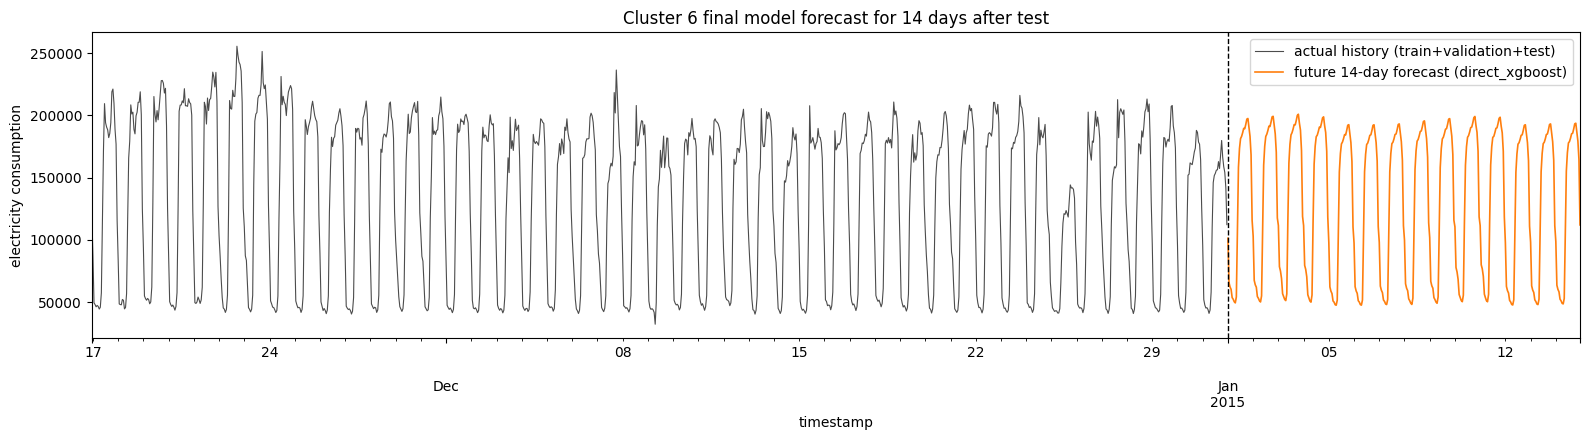

PosixPath('/Users/qrange77/Desktop/Forecasting/Proj2/Electricity-Load-Prediction/cluster6/artifacts/plots/direct_trend/future_14d_forecast_final_model.png')

In [8]:
plot_history = known_actual.loc[known_actual.index >= known_actual.index.max() - pd.Timedelta(days=45)]
fig, ax = plt.subplots(figsize=(16, 4.5))
plot_history.plot(ax=ax, label="actual history (train+validation+test)", linewidth=0.8, color="#4c4c4c")
future_pred.plot(ax=ax, label=f"future 14-day forecast ({selected_model})", linewidth=1.2, color="#ff7f0e")
ax.axvline(future_index.min(), color="black", linestyle="--", linewidth=1)
ax.set_title("Cluster 6 final model forecast for 14 days after test")
ax.set_ylabel("electricity consumption")
ax.legend()
savefig("future_14d_forecast_final_model.png")
